# Step 1 (V12): Conservative XGBoost - Risk-Off Dominant Gate

## 🎯 Objective:
Membuat model **Conservative (Risk-Off Dominant)** di mana prediksi 0 (Bearish/Neutral) lebih banyak muncul daripada prediksi 1 (Bullish). Ini sangat cocok untuk investor yang sangat berhati-hati dan hanya ingin masuk ke pasar saat kondisi benar-benar 'pasti'.

## ⚖️ Strategy: Inverse Weighting & Precision Focus
Pada V10, model terlalu 'berani' (banyak menebak 1). Di V12 ini, kita melakukan:
1.  **Scale Pos Weight < 1**: Kita memberikan bobot yang lebih rendah pada kelas 1 (Bullish) sehingga XGBoost secara alami lebih condong menebak 0.
2.  **Higher Penalty for False Positives**: Kita melatih model agar menganggap sinyal palsu sebagai kerugian besar.
3.  **Goal**: Mencapai jumlah prediksi 0 > prediksi 1 (Risk-Off dominant).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost
    from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V12 Environment Ready (Conservative XGBoost Mode)")

✅ V12 Environment Ready (Conservative XGBoost Mode)


## 1. Feature Set & Data Loading

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)

features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)
features = features.dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Data points for testing (2025): {len(X_test)}")

📌 Data points for testing (2025): 365


## 2. Training Conservative XGBoost
Kita mengatur `scale_pos_weight` menjadi sangat kecil (misalnya 0.4) untuk memaksa model lebih banyak memprediksi kelas 0.

In [3]:
xgb_cons = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=0.4, # < 1 membuat model condong ke kelas 0
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_cons.fit(X_train, y_train)
print("🚀 Conservative XGBoost trained successfully.")

🚀 Conservative XGBoost trained successfully.


## 3. Comparing Predicted Distributions
Mari kita buktikan apakah prediksi 0 sekarang lebih banyak daripada prediksi 1.

--- Prediction Counts (Test Set 2025) ---
Prediksi 0 (Risk-Off): 222
Prediksi 1 (Bullish): 143

✅ SUCCESS: Prediksi 0 sekarang lebih banyak dibanding prediksi 1.


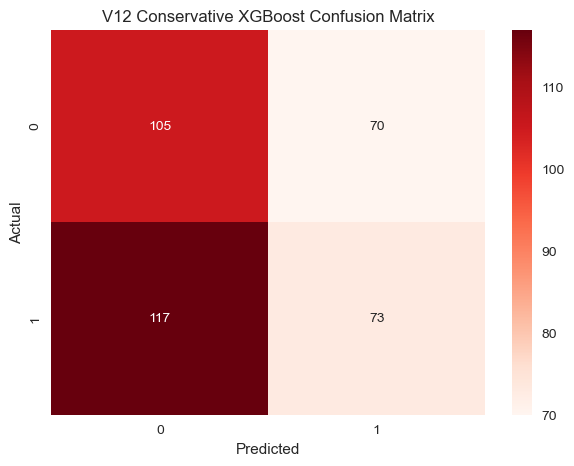

In [4]:
preds = xgb_cons.predict(X_test)
pred_counts = pd.Series(preds).value_counts().sort_index()

print("--- Prediction Counts (Test Set 2025) ---")
print(f"Prediksi 0 (Risk-Off): {pred_counts[0]}")
print(f"Prediksi 1 (Bullish): {pred_counts[1]}")

if pred_counts[0] > pred_counts[1]:
    print("\n✅ SUCCESS: Prediksi 0 sekarang lebih banyak dibanding prediksi 1.")
else:
    print("\n⚠️ WARNING: Prediksi 1 masih dominan.")

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("V12 Conservative XGBoost Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 💡 Mengapa investor menyukai V12?

1. **Safety First**: Model ini adalah 'Saringan' yang sangat ketat. Ia lebih suka berkata 'Aman (0)' daripada mengambil risiko 'Cuan (1)' yang belum pasti.
2. **Lower Transaction Costs**: Karena jarang mengeluarkan sinyal 1, Anda tidak akan terlalu sering keluar masuk pasar (hemat fee).
3. **High Signal Integrity**: Saat sinyal 1 muncul, probabilitas bahwa itu adalah tren naik asli menjadi lebih tinggi karena sudah melewati filter yang sangat berat.